## OC22 Library And Function


In [2]:
import sys
sys.path.append(r"D:\Train_thử\fairchem-tio2-s2ef")

from ocpmodels.preprocessing import AtomsToGraphs
from ocpmodels.datasets import SinglePointLmdbDataset, TrajectoryLmdbDataset, OC22LmdbDataset, LmdbDataset
import ase.io
from ase.build import bulk
from ase.build import fcc100, add_adsorbate, molecule
from ase.constraints import FixAtoms
from ase.calculators.emt import EMT
from ase.optimize import BFGS
import matplotlib.pyplot as plt
import lmdb
import pickle
from tqdm import tqdm
import torch
import os

## Structure to Energy and Forces (S2EF) LMDBs

In [3]:
# dataset = TrajectoryLmdbDataset({"src": "s2ef/"})
# dataset = OC22LmdbDataset({"src": r"D:\Train_thử\fairchem-tio2-s2ef\tio2_s2ef\oc22_data\s2ef_total_train_val_test_lmdbs\data\oc22\s2ef-total\val_ood\data.0000.lmdb"})
dataset = LmdbDataset({"src": r"D:\Train_thử\fairchem-tio2-s2ef\tio2_s2ef\oc22_data\tio2_filtered\train"})

len(dataset)

2097

## Search Sid, Fid and Index

In [4]:
target_sid = 1068 # change this to any sid you want 12032, 1068, 31757, 2714, 23315
sid_fid_map = {}  # fid → list of dataset indices

for i in range(len(dataset)):
    try:
        sample = dataset[i]
        if sample.sid == target_sid:
            fid = sample.fid
            if fid not in sid_fid_map:
                sid_fid_map[fid] = []
            sid_fid_map[fid].append(i)
    except Exception:
        continue

print(f"Found {len(sid_fid_map)} unique fid(s) for sid={target_sid}")
for fid, indices in sorted(sid_fid_map.items()):
    print(f"  fid={fid} → dataset indices: {indices}")

Found 376 unique fid(s) for sid=1068
  fid=1 → dataset indices: [968]
  fid=2 → dataset indices: [151]
  fid=3 → dataset indices: [1016]
  fid=4 → dataset indices: [1164]
  fid=5 → dataset indices: [674]
  fid=6 → dataset indices: [1600]
  fid=7 → dataset indices: [1]
  fid=8 → dataset indices: [1140]
  fid=9 → dataset indices: [1005]
  fid=10 → dataset indices: [904]
  fid=11 → dataset indices: [334]
  fid=12 → dataset indices: [147]
  fid=13 → dataset indices: [1502]
  fid=14 → dataset indices: [1073]
  fid=15 → dataset indices: [1326]
  fid=16 → dataset indices: [1747]
  fid=17 → dataset indices: [117]
  fid=18 → dataset indices: [682]
  fid=19 → dataset indices: [1229]
  fid=20 → dataset indices: [1459]
  fid=21 → dataset indices: [1400]
  fid=22 → dataset indices: [757]
  fid=23 → dataset indices: [1364]
  fid=24 → dataset indices: [237]
  fid=25 → dataset indices: [973]
  fid=26 → dataset indices: [531]
  fid=27 → dataset indices: [684]
  fid=28 → dataset indices: [1264]
  fid=29

## Calculate Energy Complex

In [5]:
import json
from collections import defaultdict

with open("D:\\Train_thử\\fairchem-tio2-s2ef\\tio2_s2ef\\oc22_data\\metadata\\tio2_data_mapping.json", "r") as f:
    metadata = json.load(f)

energy_by_ads = defaultdict(list)

# Iterate through the LMDB dataset
for data in dataset:
    sid = str(data.sid)   # dataset sid
    energy = data.y.item() if hasattr(data.y, "item") else data.y

    if sid in metadata:
        ads = metadata[sid].get("ads_symbols")
        if ads is not None:
            energy_by_ads[ads].append(energy)

# Compute average energy
avg_energy = {}

for ads, energies in energy_by_ads.items():
    avg_energy[ads] = sum(energies) / len(energies)

for ads, avg in avg_energy.items():
    print(f"{ads}: {avg:.6f} eV")

N: -787.470435 eV
H: -840.794231 eV
O: -776.512130 eV
C: -843.237876 eV
CO: -803.646709 eV


## Calculate Energy Clean Slab Of TiO2

In [6]:
import json
from collections import defaultdict

with open(r"D:\Train_thử\fairchem-tio2-s2ef\tio2_s2ef\oc22_data\metadata\tio2_data_mapping.json", "r") as f:
    metadata = json.load(f)

energy_by_sid = defaultdict(list)

for data in dataset:
    sid = str(data.sid)

    # Get traj_id from data if present, else from metadata
    traj_id = None
    if hasattr(data, "traj_id"):
        traj_id = data.traj_id
    elif sid in metadata:
        traj_id = metadata[sid].get("traj_id")

    if traj_id is None:
        continue

    # Filter only traj_id entries containing "clean"
    if "clean" not in str(traj_id):
        continue

    energy = data.y.item() if hasattr(data.y, "item") else float(data.y)
    energy_by_sid[sid].append(energy)

# Average energy per sid
avg_energy_by_sid = {
    sid: sum(vals) / len(vals)
    for sid, vals in energy_by_sid.items()
    if len(vals) > 0
}

print(f"Found {len(avg_energy_by_sid)} sids with traj_id containing 'clean'")
for sid, avg in sorted(avg_energy_by_sid.items(), key=lambda x: x[0]):
    print(f"sid={sid}: avg_energy={avg:.6f} eV")

Found 3 sids with traj_id containing 'clean'
sid=3148: avg_energy=-824.408690 eV
sid=3589: avg_energy=-787.838513 eV
sid=36509: avg_energy=-768.025361 eV


## Calculate Energy Gas Base On Article

"H":  -3.386,
"O":  -7.459,
"C":  -7.332,
"N":  -8.309,
"CO": -14.791,

## Calculate Energy Adsorbate Base On Formula
E_ad = E_complex - E_slab - E_gas

In [7]:
import json
from collections import defaultdict

E_gas = {
    "H":  -3.386,
    "O":  -7.459,
    "C":  -7.332,
    "N":  -8.309,
    "CO": -14.791,
}

with open(r"D:\Train_thử\fairchem-tio2-s2ef\tio2_s2ef\oc22_data\metadata\tio2_data_mapping.json", "r") as f:
    metadata = json.load(f)

# Build slab energy map from clean slab sids
slab_energy_by_sid = {}
for data in dataset:
    try:
        sid = str(data.sid)
    except Exception:
        continue
    if sid not in metadata:
        continue
    traj_id = metadata[sid].get("traj_id", "")
    if "clean" not in str(traj_id):
        continue
    # Use energy y
    en = data.y.item() if hasattr(data.y, "item") else float(data.y)
    slab_energy_by_sid[sid] = en

print(f"Loaded clean slab energies for {len(slab_energy_by_sid)} sids")

# Compute E_ad for each adsorbate data point, group by ads_symbols
ad_energy_by_ads = defaultdict(list)
missing = {"no_meta": 0, "no_ads": 0, "no_slab": 0, "no_gas": 0}

for data in dataset:
    try:
        sid = str(data.sid)
    except Exception:
        continue
    if sid not in metadata:
        missing["no_meta"] += 1
        continue

    info = metadata[sid]
    ads_sym = info.get("ads_symbols")
    slab_sid = info.get("slab_sid")
    traj_id = info.get("traj_id", "")

    # Optionally filter only entries from "clean" trajectories if needed
    # if "clean" not in str(traj_id):
    #     continue

    if ads_sym is None:
        missing["no_ads"] += 1
        continue
    if slab_sid is None:
        missing["no_slab"] += 1
        continue

    slab_sid = str(slab_sid)
    if slab_sid not in slab_energy_by_sid:
        missing["no_slab"] += 1
        continue

    if ads_sym not in E_gas:
        missing["no_gas"] += 1
        continue

    E_complex = data.y.item() if hasattr(data.y, "item") else float(data.y)
    E_slab = slab_energy_by_sid[slab_sid]
    E_g = E_gas[ads_sym]

    E_ad = E_complex - E_slab - E_g
    ad_energy_by_ads[ads_sym].append(E_ad)

#print("Missing counts:", missing)

avg_E_ad_by_ads = {
    ads: sum(vals) / len(vals)
    for ads, vals in ad_energy_by_ads.items()
    if len(vals) > 0
}

print("\nAverage E_ad by ads_symbols:")
for ads, avg in sorted(avg_E_ad_by_ads.items()):
    print(f"{ads}: {avg:.6f} eV  (N={len(ad_energy_by_ads[ads])})")

Loaded clean slab energies for 3 sids

Average E_ad by ads_symbols:
C: -10.847211 eV  (N=414)
CO: 0.222918 eV  (N=473)
H: -12.349566 eV  (N=376)
N: -9.125351 eV  (N=167)
O: 0.982954 eV  (N=148)


## Visualize The Results

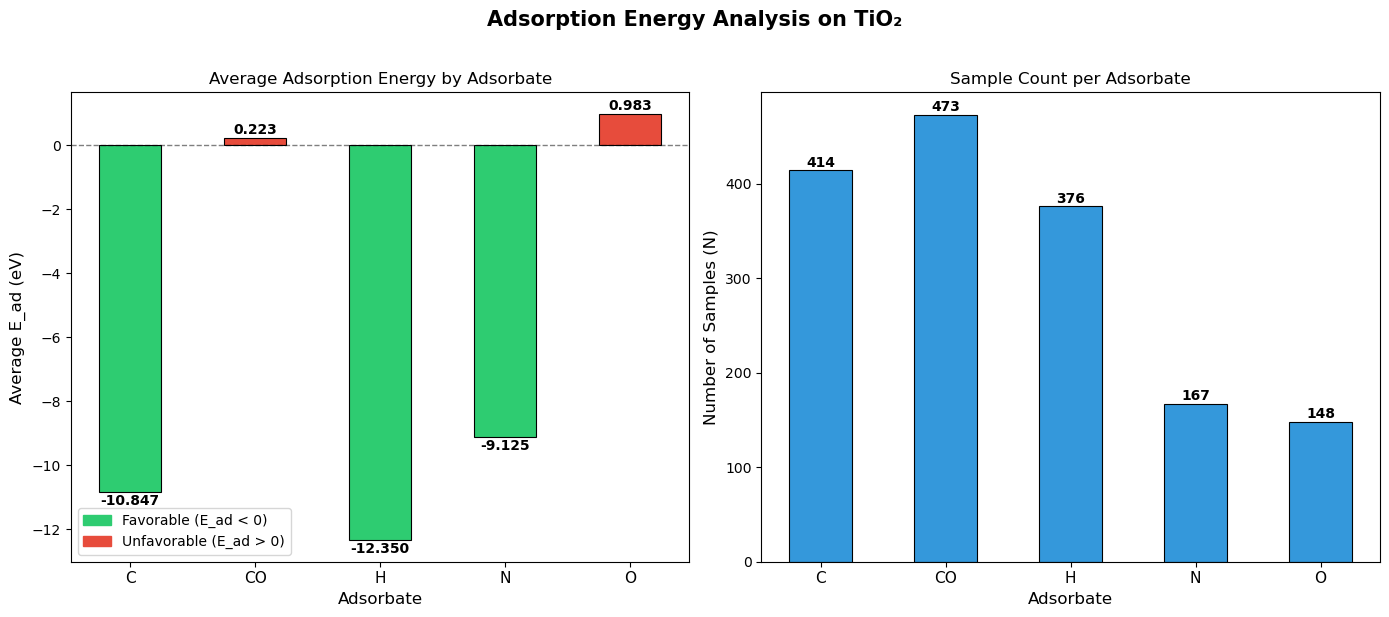

In [8]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ── Data prep ─────────────────────────────────────────────────────
ads_list  = sorted(avg_E_ad_by_ads.keys())
avg_vals  = [avg_E_ad_by_ads[a] for a in ads_list]
counts    = [len(ad_energy_by_ads[a]) for a in ads_list]
colors    = ["#e74c3c" if v > 0 else "#2ecc71" for v in avg_vals]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Adsorption Energy Analysis on TiO₂", fontsize=15, fontweight="bold", y=1.02)

# ── Plot 1: Bar chart of average E_ad ─────────────────────────────
ax1 = axes[0]
bars = ax1.bar(ads_list, avg_vals, color=colors, edgecolor="black", linewidth=0.8, width=0.5)

ax1.axhline(0, color="black", linewidth=1, linestyle="--", alpha=0.5)
ax1.set_xlabel("Adsorbate", fontsize=12)
ax1.set_ylabel("Average E_ad (eV)", fontsize=12)
ax1.set_title("Average Adsorption Energy by Adsorbate", fontsize=12)
ax1.tick_params(axis="x", labelsize=11)

# Value labels on bars
for bar, val in zip(bars, avg_vals):
    ypos = val + 0.02 if val >= 0 else val - 0.05
    ax1.text(bar.get_x() + bar.get_width() / 2, ypos,
             f"{val:.3f}", ha="center", va="bottom" if val >= 0 else "top",
             fontsize=10, fontweight="bold")

# Legend
legend_patches = [
    mpatches.Patch(color="#2ecc71", label="Favorable (E_ad < 0)"),
    mpatches.Patch(color="#e74c3c", label="Unfavorable (E_ad > 0)"),
]
ax1.legend(handles=legend_patches, fontsize=10)

# ── Plot 2: Sample count bar chart ────────────────────────────────
ax2 = axes[1]
ax2.bar(ads_list, counts, color="#3498db", edgecolor="black", linewidth=0.8, width=0.5)
ax2.set_xlabel("Adsorbate", fontsize=12)
ax2.set_ylabel("Number of Samples (N)", fontsize=12)
ax2.set_title("Sample Count per Adsorbate", fontsize=12)
ax2.tick_params(axis="x", labelsize=11)

for i, (bar, n) in enumerate(zip(ax2.patches, counts)):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
             str(n), ha="center", va="bottom", fontsize=10, fontweight="bold")

plt.tight_layout()
plt.savefig("adsorption_energy_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
#print("Chart saved to adsorption_energy_analysis.png")

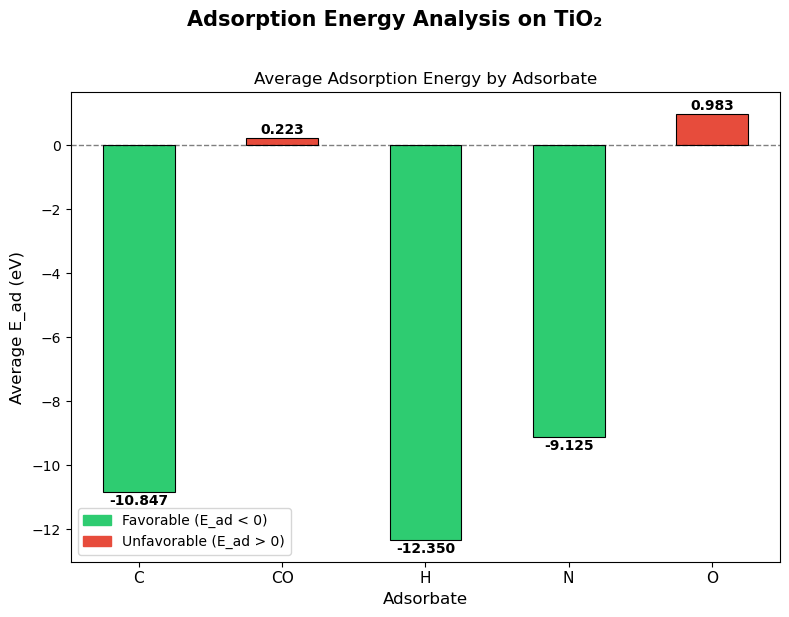

In [9]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ── Data prep ─────────────────────────────────────────────────────
ads_list  = sorted(avg_E_ad_by_ads.keys())
avg_vals  = [avg_E_ad_by_ads[a] for a in ads_list]
colors    = ["#e74c3c" if v > 0 else "#2ecc71" for v in avg_vals]

fig, ax1 = plt.subplots(figsize=(8, 6))
fig.suptitle("Adsorption Energy Analysis on TiO₂", fontsize=15, fontweight="bold", y=1.02)

# ── Bar chart of average E_ad ─────────────────────────────────────
bars = ax1.bar(ads_list, avg_vals, color=colors, edgecolor="black", linewidth=0.8, width=0.5)

ax1.axhline(0, color="black", linewidth=1, linestyle="--", alpha=0.5)
ax1.set_xlabel("Adsorbate", fontsize=12)
ax1.set_ylabel("Average E_ad (eV)", fontsize=12)
ax1.set_title("Average Adsorption Energy by Adsorbate", fontsize=12)
ax1.tick_params(axis="x", labelsize=11)

# Value labels on bars
for bar, val in zip(bars, avg_vals):
    ypos = val + 0.02 if val >= 0 else val - 0.05
    ax1.text(bar.get_x() + bar.get_width() / 2, ypos,
             f"{val:.3f}", ha="center", va="bottom" if val >= 0 else "top",
             fontsize=10, fontweight="bold")

# Legend
legend_patches = [
    mpatches.Patch(color="#2ecc71", label="Favorable (E_ad < 0)"),
    mpatches.Patch(color="#e74c3c", label="Unfavorable (E_ad > 0)"),
]
ax1.legend(handles=legend_patches, fontsize=10)

plt.tight_layout()
plt.savefig("adsorption_energy_analysis.png", dpi=150, bbox_inches="tight")
plt.show()